# Step 4. SHAP 분석 — 어떤 공정 변수가 불량에 영향을 주는가

**목표**: Step 3에서 선택한 RandomForest 모델을 SHAP으로 분해해, 모델이 불량을 예측할 때 **어떤 센서(공정 변수)에 근거하는지**를 정량적으로 해석한다.

> 이 프로젝트의 핵심 메시지: *"단순히 모델 정확도를 높이는 것이 아니라, 어떤 공정 변수가 수율 불량에 영향을 주는지 해석하는 데 집중했습니다."*

**구성**
1. 모델·데이터 로드, TreeExplainer 생성
2. 전체 피처 중요도 — Summary plot (상위 20, bar)
3. 방향성까지 보는 beeswarm summary plot
4. 개별 예측 설명 — Waterfall plot (불량으로 맞힌 샘플 1개)
5. 상위 피처 해석 + 포트폴리오 인사이트

## 0. 환경 설정 · 모델/데이터 로드 · Explainer 생성

In [1]:
# 라이브러리 import
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib
import shap

# 한글 폰트 설정
# SHAP waterfall은 음수 라벨에 유니코드 MINUS(U+2212)를 쓰는데 AppleGothic엔 이 글리프가 없다.
# 한글과 MINUS를 모두 포함한 'Arial Unicode MS'를 사용해 □ 깨짐을 방지한다.
sns.set_style('whitegrid')
mpl.rcParams['font.family'] = 'Arial Unicode MS'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

FIG_DIR = os.path.join('..', 'outputs', 'figures')
PROC_DIR = os.path.join('..', 'data', 'processed')
MODEL_DIR = os.path.join('..', 'outputs', 'models')
print('shap', shap.__version__, '| 준비 완료')

shap 0.49.1 | 준비 완료


In [2]:
# Step 3에서 저장한 RandomForest(선택 모델)와 임계값 로드
bundle = joblib.load(os.path.join(MODEL_DIR, 'random_forest.joblib'))
model, threshold = bundle['model'], bundle['threshold']

# 전처리 데이터 로드 (test로 해석 — 모델이 실제로 마주하는 분포)
data = np.load(os.path.join(PROC_DIR, 'secom_processed.npz'), allow_pickle=True)
X_test, y_test = data['X_test'], data['y_test']
feature_names = list(data['feature_names'])

# 보기 좋게 DataFrame으로 (SHAP plot의 축 라벨에 센서명이 표시됨)
X_test_df = pd.DataFrame(X_test, columns=feature_names)
print(f'모델: RandomForest (임계값 {threshold:.3f})')
print(f'해석 대상 test: {X_test_df.shape}, 불량 {int(y_test.sum())}개')

모델: RandomForest (임계값 0.320)
해석 대상 test: (314, 450), 불량 21개


In [3]:
# TreeExplainer 생성 후 test 전체에 대한 SHAP 값 계산
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_test_df)

# RF 이진분류는 SHAP 출력 형태가 버전에 따라 다름 → 불량(class 1) 기준으로 통일
if isinstance(sv, list):                      # [class0, class1] 형태
    shap_vals = sv[1]
    base_value = explainer.expected_value[1]
elif sv.ndim == 3:                            # (n, features, classes) 형태
    shap_vals = sv[:, :, 1]
    base_value = explainer.expected_value[1]
else:                                          # (n, features)
    shap_vals = sv
    base_value = explainer.expected_value

print('SHAP 값 shape:', shap_vals.shape, '| base value(불량 기준):', round(float(base_value), 4))

SHAP 값 shape: (314, 450) | base value(불량 기준): 0.4989


## 1. 전체 피처 중요도 — Summary plot (상위 20, bar)

각 센서가 불량 예측에 기여한 정도(평균 |SHAP|)를 크기 순으로 본다. 상위에 있을수록 모델이 불량 판정에 크게 의존하는 공정 변수다.

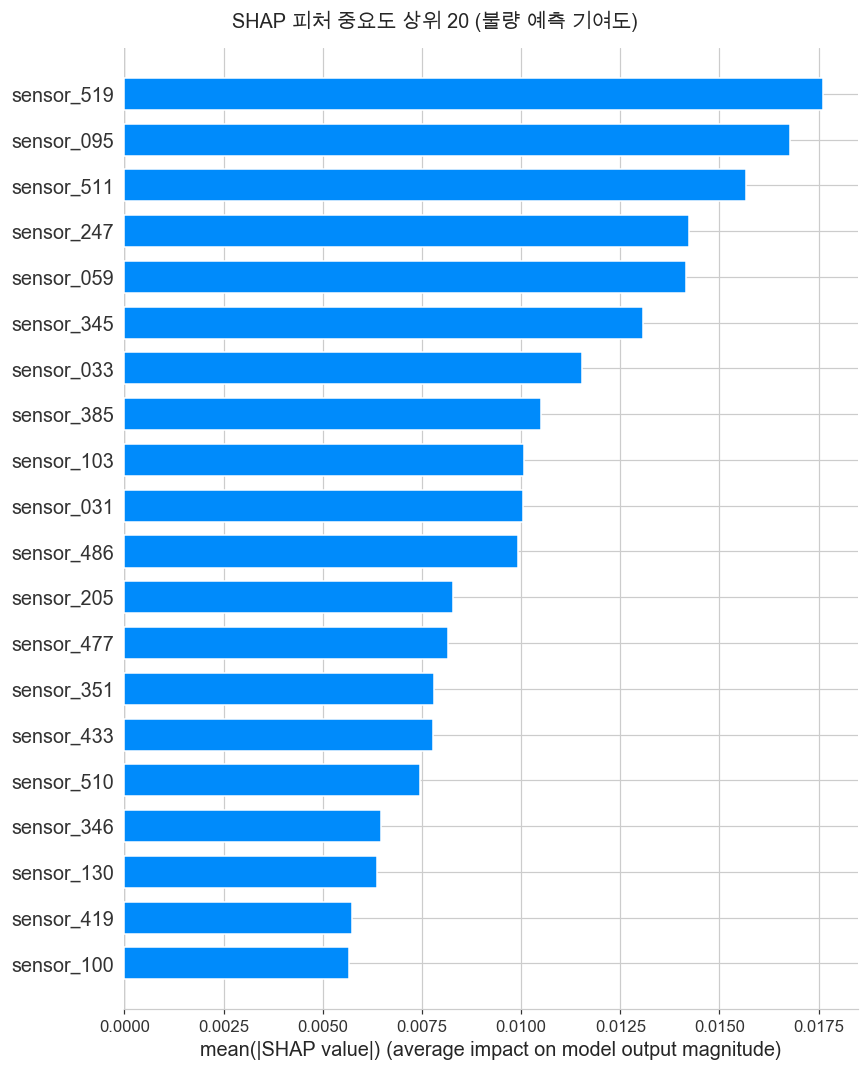

In [4]:
# 상위 20개 피처 중요도 (bar)
shap.summary_plot(shap_vals, X_test_df, plot_type='bar', max_display=20, show=False)
fig = plt.gcf()
fig.suptitle('SHAP 피처 중요도 상위 20 (불량 예측 기여도)', y=1.02, fontsize=13)
fig.savefig(os.path.join(FIG_DIR, '08_shap_summary_bar.png'), bbox_inches='tight')
plt.show()

In [5]:
# 상위 20 피처를 표로도 정리 (평균 |SHAP| 기준)
mean_abs = np.abs(shap_vals).mean(axis=0)
imp = (pd.DataFrame({'sensor': feature_names, 'mean_abs_shap': mean_abs})
       .sort_values('mean_abs_shap', ascending=False)
       .head(20).reset_index(drop=True))
imp.index += 1
print('SHAP 기준 불량 예측 핵심 센서 TOP 20')
print(imp.round(5))
top_sensors = imp['sensor'].tolist()

SHAP 기준 불량 예측 핵심 센서 TOP 20
        sensor  mean_abs_shap
1   sensor_519        0.01761
2   sensor_095        0.01678
3   sensor_511        0.01568
4   sensor_247        0.01423
5   sensor_059        0.01416
6   sensor_345        0.01307
7   sensor_033        0.01154
8   sensor_385        0.01049
9   sensor_103        0.01007
10  sensor_031        0.01006
11  sensor_486        0.00991
12  sensor_205        0.00829
13  sensor_477        0.00815
14  sensor_351        0.00781
15  sensor_433        0.00779
16  sensor_510        0.00746
17  sensor_346        0.00648
18  sensor_130        0.00637
19  sensor_419        0.00574
20  sensor_100        0.00567


## 2. 방향성까지 보는 beeswarm summary plot

bar는 "크기"만 보여주지만, beeswarm은 **센서 값이 높을 때(빨강)/낮을 때(파랑)** 불량 확률을 올리는지 내리는지 **방향**까지 보여준다. 공정 해석에서 가장 중요한 그림.

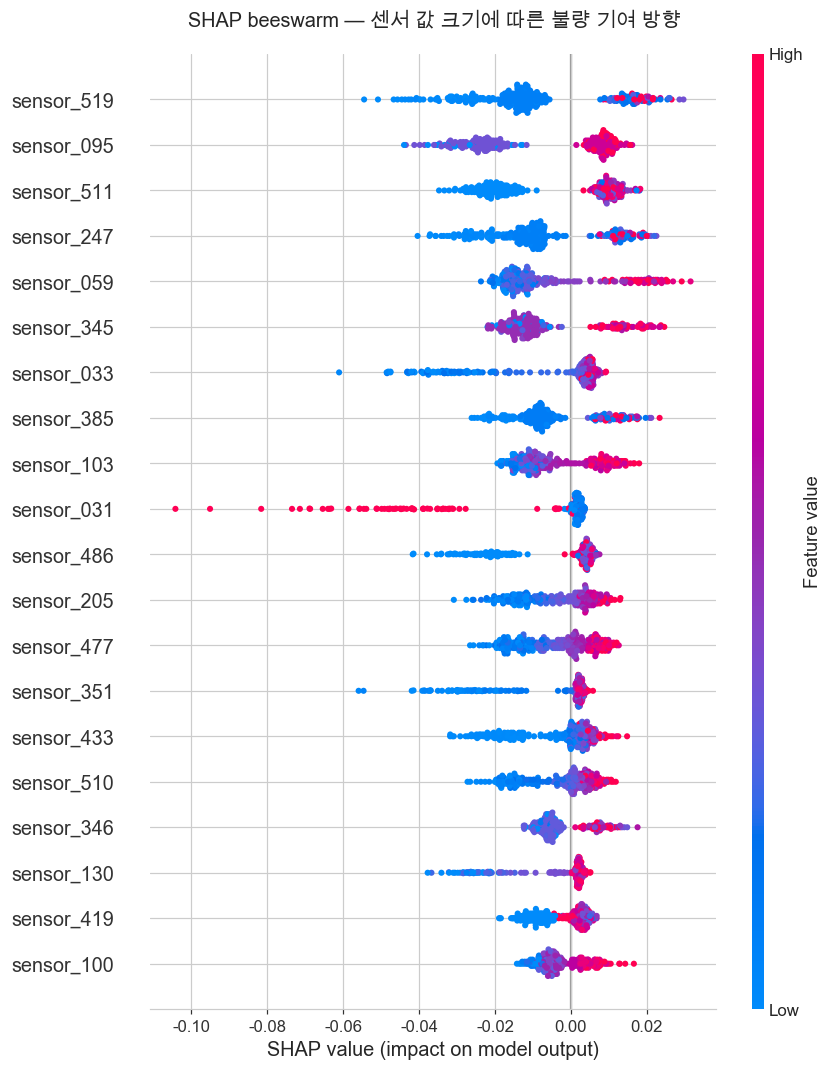

In [6]:
# beeswarm summary plot (상위 20)
shap.summary_plot(shap_vals, X_test_df, max_display=20, show=False)
fig = plt.gcf()
fig.suptitle('SHAP beeswarm — 센서 값 크기에 따른 불량 기여 방향', y=1.02, fontsize=13)
fig.savefig(os.path.join(FIG_DIR, '09_shap_beeswarm.png'), bbox_inches='tight')
plt.show()

## 3. 개별 예측 설명 — Waterfall plot

모델이 **실제 불량을 불량으로 맞힌(True Positive)** 샘플 하나를 골라, 어떤 센서가 그 예측을 끌어올렸는지 분해한다.
기준값(base value)에서 출발해 각 센서의 SHAP 기여가 더해져 최종 불량 확률에 도달하는 과정을 보여준다.

In [7]:
# 불량으로 맞힌(TP) 샘플 중 불량 확률이 가장 높은 케이스 선택
proba = model.predict_proba(X_test_df)[:, 1]
pred = (proba >= threshold).astype(int)
tp_idx = np.where((pred == 1) & (y_test == 1))[0]   # 실제 불량 & 불량 예측

if len(tp_idx) > 0:
    i = tp_idx[np.argmax(proba[tp_idx])]
    kind = 'True Positive (불량을 불량으로 정확히 예측)'
else:  # 안전장치: TP가 없으면 불량 확률 최고 샘플
    i = int(np.argmax(proba))
    kind = '불량 확률 최고 샘플'
print(f'선택 샘플 index={i} | 불량확률={proba[i]:.3f} | 실제={int(y_test[i])} | {kind}')

선택 샘플 index=249 | 불량확률=0.400 | 실제=1 | True Positive (불량을 불량으로 정확히 예측)


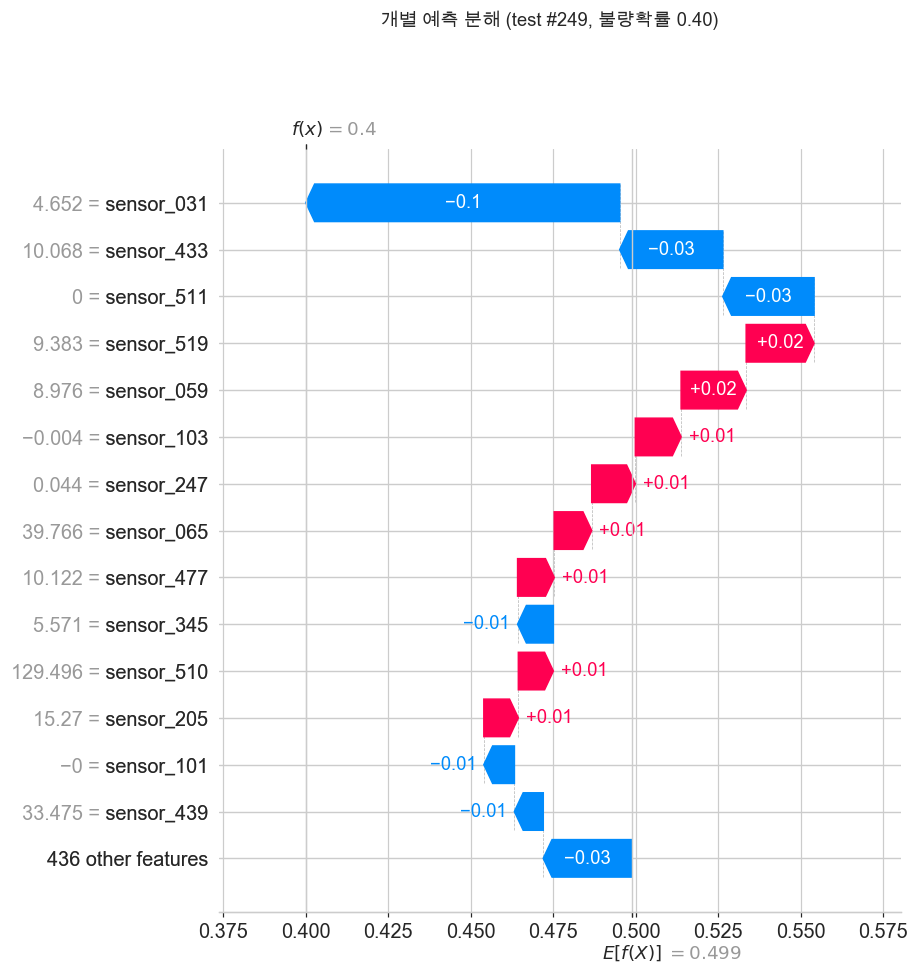

In [8]:
# Waterfall plot: 선택 샘플의 예측을 센서별 기여로 분해
exp_one = shap.Explanation(
    values=shap_vals[i],
    base_values=base_value,
    data=X_test_df.iloc[i].values,
    feature_names=feature_names,
)
shap.plots.waterfall(exp_one, max_display=15, show=False)
fig = plt.gcf()
fig.suptitle(f'개별 예측 분해 (test #{i}, 불량확률 {proba[i]:.2f})', y=1.02, fontsize=12)
fig.savefig(os.path.join(FIG_DIR, '10_shap_waterfall.png'), bbox_inches='tight')
plt.show()

## 4. 상위 피처 해석 (공정 관점)

In [9]:
# 상위 센서들의 평균 기여를 다시 한 번 요약 출력
print('불량 예측을 가장 크게 좌우한 공정 변수 TOP 10')
for rank, (s, v) in enumerate(zip(imp['sensor'][:10], imp['mean_abs_shap'][:10]), 1):
    print(f'  {rank:>2}. {s}  (평균 |SHAP| = {v:.5f})')

불량 예측을 가장 크게 좌우한 공정 변수 TOP 10
   1. sensor_519  (평균 |SHAP| = 0.01761)
   2. sensor_095  (평균 |SHAP| = 0.01678)
   3. sensor_511  (평균 |SHAP| = 0.01568)
   4. sensor_247  (평균 |SHAP| = 0.01423)
   5. sensor_059  (평균 |SHAP| = 0.01416)
   6. sensor_345  (평균 |SHAP| = 0.01307)
   7. sensor_033  (평균 |SHAP| = 0.01154)
   8. sensor_385  (평균 |SHAP| = 0.01049)
   9. sensor_103  (평균 |SHAP| = 0.01007)
  10. sensor_031  (평균 |SHAP| = 0.01006)


> **공정 관점 해석**
>
> - SECOM 데이터의 센서명은 익명화되어 있어(`sensor_xxx`) 물리적 의미가 공개되지 않는다. 따라서 위 TOP 센서들은 **"불량 판정에 가장 큰 영향을 주는 공정 계측 지점"의 후보 목록**으로 해석한다.
> - 실제 팹(fab)에서는 이 sensor_id를 공정 트레이서빌리티 시스템의 실제 계측 항목(예: 식각 시간, 챔버 압력·온도, CMP 슬러리 유량 등)과 매핑하면, **"어떤 설비·레시피 파라미터를 우선 점검·관리해야 하는지"** 우선순위가 곧바로 도출된다.
> - beeswarm에서 특정 센서가 **높은 값(빨강)일 때 SHAP이 양(+)** 으로 쏠리면 "그 공정 값이 높을수록 불량 위험↑"을 뜻한다. 이는 해당 파라미터의 **상한 관리(SPC 관리한계)** 강화로 연결할 수 있는 실무 신호다.
> - waterfall은 개별 웨이퍼 단위로 "왜 이 웨이퍼가 불량으로 예측됐는가"를 설명하므로, **불량 원인 분석(FA) 리포트**에 그대로 첨부 가능한 근거가 된다.

### 포트폴리오 최종 인사이트

- **모델을 '블랙박스'로 두지 않았다**: SHAP으로 590개 센서 중 불량 예측을 좌우하는 핵심 공정 변수 20개를 추려, 모델의 판단 근거를 정량적으로 제시했다.
- **전역(summary) + 국소(waterfall) 해석 결합**: 전체적으로 중요한 변수(어디를 관리할지)와 개별 웨이퍼의 불량 근거(왜 이 웨이퍼인지)를 모두 설명해, 현장에서 바로 쓸 수 있는 형태로 만들었다.
- **PE 직무 연결**: "수율 불량의 주요 인자 후보를 데이터로 식별하고, 그 변수의 관리 방향(상·하한)까지 제시"하는 흐름은 Product Engineering의 수율 개선 업무와 직접 맞닿아 있다.

> **한 줄 요약**: 정확도 경쟁이 아니라, *어떤 공정 변수가 수율 불량에 영향을 주는지*를 SHAP으로 해석·제시하는 데 집중한 프로젝트.

---
**프로젝트 완료** — EDA → 전처리(누수 방지) → 모델링(임계값 튜닝) → SHAP 해석의 전 과정을 노트북으로 재현 가능하게 구성했다.